# Comparative Analysis of Custom CNN and Transfer Learning Models with Explainable AI
### Fruit Freshness Detection — Custom CNN vs MobileNetV2 vs ResNet50 (Grad-CAM + SHAP)

This notebook trains and compares three image-classification models on the
**Fruits fresh and rotten for classification** dataset (6 classes: fresh/rotten apple, banana, orange),
then explains them with **Grad-CAM** and **SHAP**.

**All figures are saved as PDF** in `outputs/figures/` and **all tables as CSV** in `outputs/tables/`.

**Before running (3 settings in the right-hand panel):**
1. **Accelerator -> GPU** (T4 or P100).
2. **Internet -> ON** — required so Keras can download the ImageNet weights for MobileNetV2/ResNet50.
3. **Add Input** -> attach the *fruits-fresh-and-rotten-for-classification* dataset (mounts under `/kaggle/input/`).

Then **Run All**. Lower `EPOCHS` in the config cell if you are short on GPU time.

In [1]:
# ============================================================
# Setup, imports, reproducibility, output folders
# ============================================================
import os, time, glob, random, warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # quiet TF startup logs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
tf.get_logger().setLevel("ERROR")

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus if gpus else "NONE  (enable GPU in Settings -> Accelerator)")

# Output directories
OUT      = "/kaggle/working/outputs"
FIG_DIR  = os.path.join(OUT, "figures")
TAB_DIR  = os.path.join(OUT, "tables")
MODEL_DIR= os.path.join(OUT, "models")
for d in (FIG_DIR, TAB_DIR, MODEL_DIR):
    os.makedirs(d, exist_ok=True)

def save_fig(fig, name):
    "Save a matplotlib figure as PDF in the figures folder."
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, format="pdf", bbox_inches="tight")
    print("saved figure ->", path)

def save_table(df, name):
    "Save a DataFrame as CSV in the tables folder."
    path = os.path.join(TAB_DIR, name)
    df.to_csv(path, index=True)
    print("saved table  ->", path)


E0000 00:00:1782474258.366504      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782474258.418200      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782474258.847439      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782474258.847473      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782474258.847476      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782474258.847478      58 computation_placer.cc:177] computation placer already registered. Please check linka

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# ============================================================
# Configuration  (lower EPOCHS if you are short on GPU time)
# ============================================================
IMG          = 224          # ResNet50 / MobileNetV2 expect 224x224
BATCH        = 32
EPOCHS       = 10           # head training epochs
DO_FINETUNE  = True         # unfreeze top of pretrained base for a short 2nd pass
FINE_TUNE_EPOCHS = 4
NUM_CLASSES  = None         # set automatically after we read the data
MODELS       = ["Custom CNN", "MobileNetV2", "ResNet50"]
SHAP_N       = 3            # number of test images explained with SHAP
SHAP_MAX_EVALS = 300        # SHAP budget per image (higher = sharper but slower)
AUTOTUNE     = tf.data.AUTOTUNE

# Last convolutional layer used by Grad-CAM for each model
LAST_CONV = {
    "Custom CNN":  "last_conv",
    "MobileNetV2": "out_relu",
    "ResNet50":    "conv5_block3_out",
}


## Phase 0 — Locate the dataset under `/kaggle/input`
Robustly finds the `train/` and `test/` folders (the ones containing `fresh*`/`rotten*` subfolders),
so it works regardless of the exact mount path.

In [4]:
def find_split(split):
    "Find a train/ or test/ folder whose subfolders look like fresh/rotten classes."
    for p in glob.glob(f"/kaggle/input/**/{split}", recursive=True):
        if not os.path.isdir(p):
            continue
        subs = [d for d in os.listdir(p) if os.path.isdir(os.path.join(p, d))]
        if subs and any(("fresh" in s.lower() or "rotten" in s.lower()) for s in subs):
            return p
    return None

TRAIN_DIR = find_split("train")
TEST_DIR  = find_split("test")

assert TRAIN_DIR and TEST_DIR, (
    "Could not find train/test folders. Use 'Add Input' to attach the dataset, "
    "then check /kaggle/input. Found:\n" + "\n".join(glob.glob('/kaggle/input/*')))

print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR :", TEST_DIR)
print("Classes  :", sorted(os.listdir(TRAIN_DIR)))


TRAIN_DIR: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/train
TEST_DIR : /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/test
Classes  : ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']


## Phase 1 — Dataset description + sample grid (Figure 1)
Produces `dataset_description.csv` and `fig01_dataset_samples.pdf`.

In [5]:
# ---- Per-class image counts -> dataset_description.csv ----
class_names = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(class_names)

rows = []
for c in class_names:
    n_tr = len(glob.glob(os.path.join(TRAIN_DIR, c, "*")))
    n_te = len(glob.glob(os.path.join(TEST_DIR,  c, "*")))
    rows.append({"Class": c, "Train Images": n_tr, "Test Images": n_te,
                 "Total": n_tr + n_te})
desc = pd.DataFrame(rows)
desc.loc["TOTAL"] = ["ALL", desc["Train Images"].sum(), desc["Test Images"].sum(),
                     desc["Total"].sum()]
print(desc)
print("\nNumber of classes:", NUM_CLASSES, "| Input size:", f"{IMG}x{IMG}x3")
save_table(desc.set_index("Class"), "dataset_description.csv")


               Class  Train Images  Test Images  Total
0        freshapples          1693          395   2088
1        freshbanana          1581          381   1962
2       freshoranges          1466          388   1854
3       rottenapples          2342          601   2943
4       rottenbanana          2224          530   2754
5      rottenoranges          1595          403   1998
TOTAL            ALL         10901         2698  13599

Number of classes: 6 | Input size: 224x224x3
saved table  -> /kaggle/working/outputs/tables/dataset_description.csv


saved figure -> /kaggle/working/outputs/figures/fig01_dataset_samples.pdf


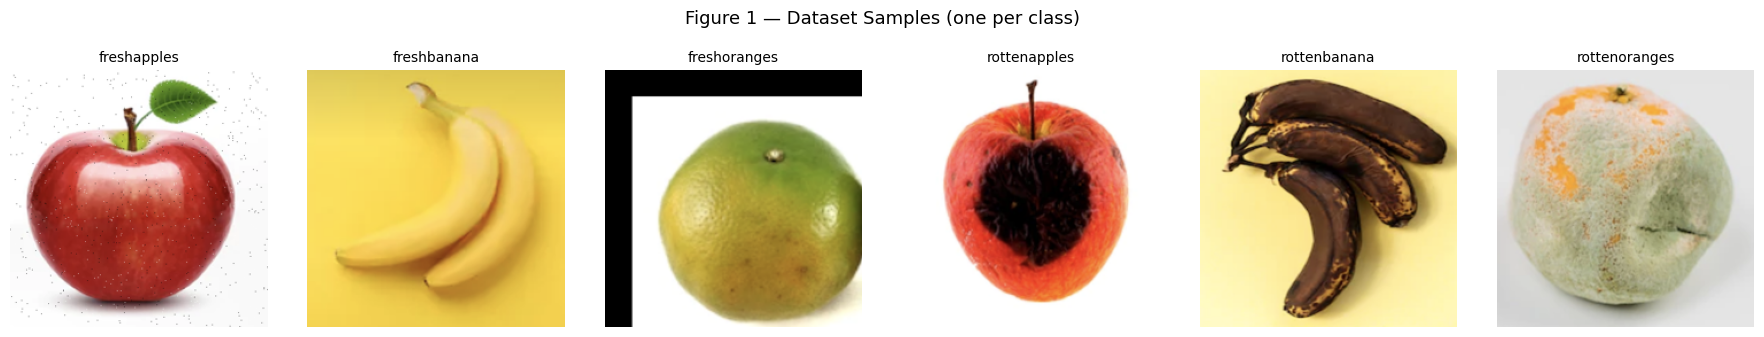

In [6]:
# ---- Figure 1: one sample image per class ----
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(3 * NUM_CLASSES, 3.2))
if NUM_CLASSES == 1:
    axes = [axes]
for ax, c in zip(axes, class_names):
    f = glob.glob(os.path.join(TRAIN_DIR, c, "*"))[0]
    ax.imshow(Image.open(f).convert("RGB").resize((IMG, IMG)))
    ax.set_title(c, fontsize=10)
    ax.axis("off")
fig.suptitle("Figure 1 — Dataset Samples (one per class)", y=1.04, fontsize=13)
plt.tight_layout()
save_fig(fig, "fig01_dataset_samples.pdf")
plt.show()


## Phase 2 — Data pipeline with **per-model preprocessing**
The three models need **different** input normalisation. Sharing one normalisation across
all three is the classic bug that silently wrecks accuracy — each model gets its own
`preprocess_input` here.

* Custom CNN -> rescale to `[0,1]`
* MobileNetV2 -> `mobilenet_v2.preprocess_input` (scales to `[-1,1]`)
* ResNet50 -> `resnet50.preprocess_input` (caffe-style BGR mean subtraction)

In [7]:
# Raw datasets (float32 in [0,255]); validation split carved out of train/
raw_train = keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="training", seed=SEED,
    image_size=(IMG, IMG), batch_size=BATCH, label_mode="categorical")
raw_val = keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="validation", seed=SEED,
    image_size=(IMG, IMG), batch_size=BATCH, label_mode="categorical")
raw_test = keras.utils.image_dataset_from_directory(
    TEST_DIR, shuffle=False, image_size=(IMG, IMG),
    batch_size=BATCH, label_mode="categorical")

class_names = raw_train.class_names      # canonical class order
NUM_CLASSES = len(class_names)
print("Class order:", class_names)

# Per-model preprocessing
preprocess_map = {
    "Custom CNN":  lambda x: x / 255.0,
    "MobileNetV2": keras.applications.mobilenet_v2.preprocess_input,
    "ResNet50":    keras.applications.resnet50.preprocess_input,
}

# Light augmentation (training only)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
], name="augmentation")

def make_ds(name):
    "Return (train, val, test) datasets preprocessed for the given model."
    pf = preprocess_map[name]
    tr = raw_train.map(lambda x, y: (pf(data_augmentation(x, training=True)), y),
                       num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    va = raw_val.map(lambda x, y: (pf(x), y),
                     num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    te = raw_test.map(lambda x, y: (pf(x), y),
                      num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    return tr, va, te

# Ground-truth labels for the test set (order is fixed: shuffle=False)
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in raw_test], axis=0)
print("Test labels:", y_true.shape[0])


Found 10901 files belonging to 6 classes.
Using 8721 files for training.


I0000 00:00:1782474444.959024      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782474444.965186      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 10901 files belonging to 6 classes.
Using 2180 files for validation.
Found 2698 files belonging to 6 classes.
Class order: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']
Test labels: 2698


## Phase 3 — Build the three models (architecture table)
Produces `model_architecture.csv` and saves each `model.summary()` to a text file.
Transfer models are built **functionally** with `input_tensor=` so their conv layers stay
top-level — that makes Grad-CAM straightforward.

In [8]:
def build_custom_cnn():
    inp = keras.Input((IMG, IMG, 3))
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu", name="last_conv")(x)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return keras.Model(inp, out, name="Custom_CNN"), None

def build_transfer(base_fn, name):
    inp = keras.Input((IMG, IMG, 3))
    try:
        base = base_fn(include_top=False, weights="imagenet", input_tensor=inp)
    except Exception as e:
        raise RuntimeError(
            f"Could not download ImageNet weights for {name}. "
            "Turn Internet ON (right panel -> Internet) and re-run."
        ) from e
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return keras.Model(inp, out, name=name.replace(" ", "_")), base

builders = {
    "Custom CNN":  lambda: build_custom_cnn(),
    "MobileNetV2": lambda: build_transfer(keras.applications.MobileNetV2, "MobileNetV2"),
    "ResNet50":    lambda: build_transfer(keras.applications.ResNet50, "ResNet50"),
}

models, bases, arch_rows = {}, {}, []
for name in MODELS:
    m, base = builders[name]()
    models[name], bases[name] = m, base
    trainable = int(sum(np.prod(v.shape) for v in m.trainable_variables))
    arch_rows.append({
        "Model": name, "Input Size": f"{IMG}x{IMG}x3",
        "Total Params": int(m.count_params()),
        "Trainable Params (head)": trainable,
        "Layers": len(m.layers), "Output Classes": NUM_CLASSES,
    })
    with open(os.path.join(MODEL_DIR, f"summary_{name.replace(' ', '_')}.txt"), "w") as fh:
        m.summary(print_fn=lambda s: fh.write(s + "\n"))

arch_df = pd.DataFrame(arch_rows).set_index("Model")
print(arch_df)
save_table(arch_df, "model_architecture.csv")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


            Input Size  Total Params  Trainable Params (head)  Layers  \
Model                                                                   
Custom CNN   224x224x3        259526                   258822      17   
MobileNetV2  224x224x3       2265670                     7686     157   
ResNet50     224x224x3      23600006                    12294     178   

             Output Classes  
Model                        
Custom CNN                6  
MobileNetV2               6  
ResNet50                  6  
saved table  -> /kaggle/working/outputs/tables/model_architecture.csv


## Phase 4 — Train all three models (records training time + history)
Same input size, seed, batch size and epoch budget for a fair comparison.
Transfer models then get a short low-LR fine-tuning pass (BatchNorm kept frozen).

In [9]:
def train_model(name):
    model, base = models[name], bases[name]
    tr, va, te = make_ds(name)
    cbs = [
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4,
                                      restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    ]
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="categorical_crossentropy", metrics=["accuracy"])
    t0 = time.time()
    print(f"\n=== Training {name} (head) ===")
    h = model.fit(tr, validation_data=va, epochs=EPOCHS, callbacks=cbs, verbose=2)
    hist = {k: list(v) for k, v in h.history.items()}

    if base is not None and DO_FINETUNE:
        print(f"=== Fine-tuning {name} (top layers) ===")
        base.trainable = True
        for l in base.layers[:-30]:
            l.trainable = False
        for l in base.layers:                      # keep BatchNorm frozen
            if isinstance(l, layers.BatchNormalization):
                l.trainable = False
        model.compile(optimizer=keras.optimizers.Adam(1e-5),
                      loss="categorical_crossentropy", metrics=["accuracy"])
        h2 = model.fit(tr, validation_data=va, epochs=FINE_TUNE_EPOCHS,
                       callbacks=cbs, verbose=2)
        for k, v in h2.history.items():
            hist.setdefault(k, []).extend(list(v))

    train_time = time.time() - t0
    model.save(os.path.join(MODEL_DIR, f"{name.replace(' ', '_')}.keras"))
    return hist, train_time, te

histories, train_times, test_ds_map = {}, {}, {}
for name in MODELS:
    histories[name], train_times[name], test_ds_map[name] = train_model(name)
    print(f"{name}: trained in {train_times[name]:.1f}s")



=== Training Custom CNN (head) ===
Epoch 1/10


I0000 00:00:1782474480.749603     144 service.cc:152] XLA service 0x788ea00024e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782474480.749659     144 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782474480.749666     144 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782474481.628372     144 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782474488.498079     144 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


273/273 - 76s - 277ms/step - accuracy: 0.7975 - loss: 0.5831 - val_accuracy: 0.1665 - val_loss: 3.8495 - learning_rate: 0.0010
Epoch 2/10
273/273 - 47s - 172ms/step - accuracy: 0.8634 - loss: 0.3980 - val_accuracy: 0.8206 - val_loss: 0.5020 - learning_rate: 0.0010
Epoch 3/10
273/273 - 47s - 173ms/step - accuracy: 0.8802 - loss: 0.3314 - val_accuracy: 0.8670 - val_loss: 0.3608 - learning_rate: 0.0010
Epoch 4/10
273/273 - 47s - 174ms/step - accuracy: 0.9041 - loss: 0.2670 - val_accuracy: 0.7509 - val_loss: 0.8337 - learning_rate: 0.0010
Epoch 5/10
273/273 - 47s - 173ms/step - accuracy: 0.9090 - loss: 0.2565 - val_accuracy: 0.9009 - val_loss: 0.2642 - learning_rate: 0.0010
Epoch 6/10
273/273 - 47s - 172ms/step - accuracy: 0.9176 - loss: 0.2233 - val_accuracy: 0.8936 - val_loss: 0.3147 - learning_rate: 0.0010
Epoch 7/10
273/273 - 47s - 172ms/step - accuracy: 0.9228 - loss: 0.2134 - val_accuracy: 0.9005 - val_loss: 0.2936 - learning_rate: 0.0010
Epoch 8/10
273/273 - 47s - 172ms/step - accur

## Phase 5 — Evaluation: metrics, confusion matrices, training curves
Produces `evaluation_results.csv`, one `classification_report_*.csv` and
`confusion_matrix_*.csv` per model, plus `fig03_training_curves.pdf` and
`fig04_confusion_matrices.pdf`.

In [10]:
eval_rows, preds_map = [], {}
for name in MODELS:
    proba = models[name].predict(test_ds_map[name], verbose=0)
    y_pred = np.argmax(proba, axis=1)
    preds_map[name] = y_pred

    rep = classification_report(y_true, y_pred, target_names=class_names,
                                output_dict=True, zero_division=0)
    save_table(pd.DataFrame(rep).transpose(),
               f"classification_report_{name.replace(' ', '_')}.csv")

    cm = confusion_matrix(y_true, y_pred)
    save_table(pd.DataFrame(cm, index=class_names, columns=class_names),
               f"confusion_matrix_{name.replace(' ', '_')}.csv")

    eval_rows.append({
        "Model": name,
        "Accuracy":  round(rep["accuracy"], 4),
        "Precision": round(rep["macro avg"]["precision"], 4),
        "Recall":    round(rep["macro avg"]["recall"], 4),
        "F1-Score":  round(rep["macro avg"]["f1-score"], 4),
        "Training Time (s)": round(train_times[name], 1),
        "Parameters": int(models[name].count_params()),
    })

eval_df = pd.DataFrame(eval_rows).set_index("Model")
print(eval_df)
save_table(eval_df, "evaluation_results.csv")


saved table  -> /kaggle/working/outputs/tables/classification_report_Custom_CNN.csv
saved table  -> /kaggle/working/outputs/tables/confusion_matrix_Custom_CNN.csv
saved table  -> /kaggle/working/outputs/tables/classification_report_MobileNetV2.csv
saved table  -> /kaggle/working/outputs/tables/confusion_matrix_MobileNetV2.csv
saved table  -> /kaggle/working/outputs/tables/classification_report_ResNet50.csv
saved table  -> /kaggle/working/outputs/tables/confusion_matrix_ResNet50.csv
             Accuracy  Precision  Recall  F1-Score  Training Time (s)  \
Model                                                                   
Custom CNN     0.9589     0.9572  0.9654    0.9601              500.1   
MobileNetV2    0.9956     0.9954  0.9951    0.9952              726.2   
ResNet50       0.9978     0.9979  0.9976    0.9978              830.9   

             Parameters  
Model                    
Custom CNN       259526  
MobileNetV2     2265670  
ResNet50       23600006  
saved table  -> /

saved figure -> /kaggle/working/outputs/figures/fig03_training_curves.pdf


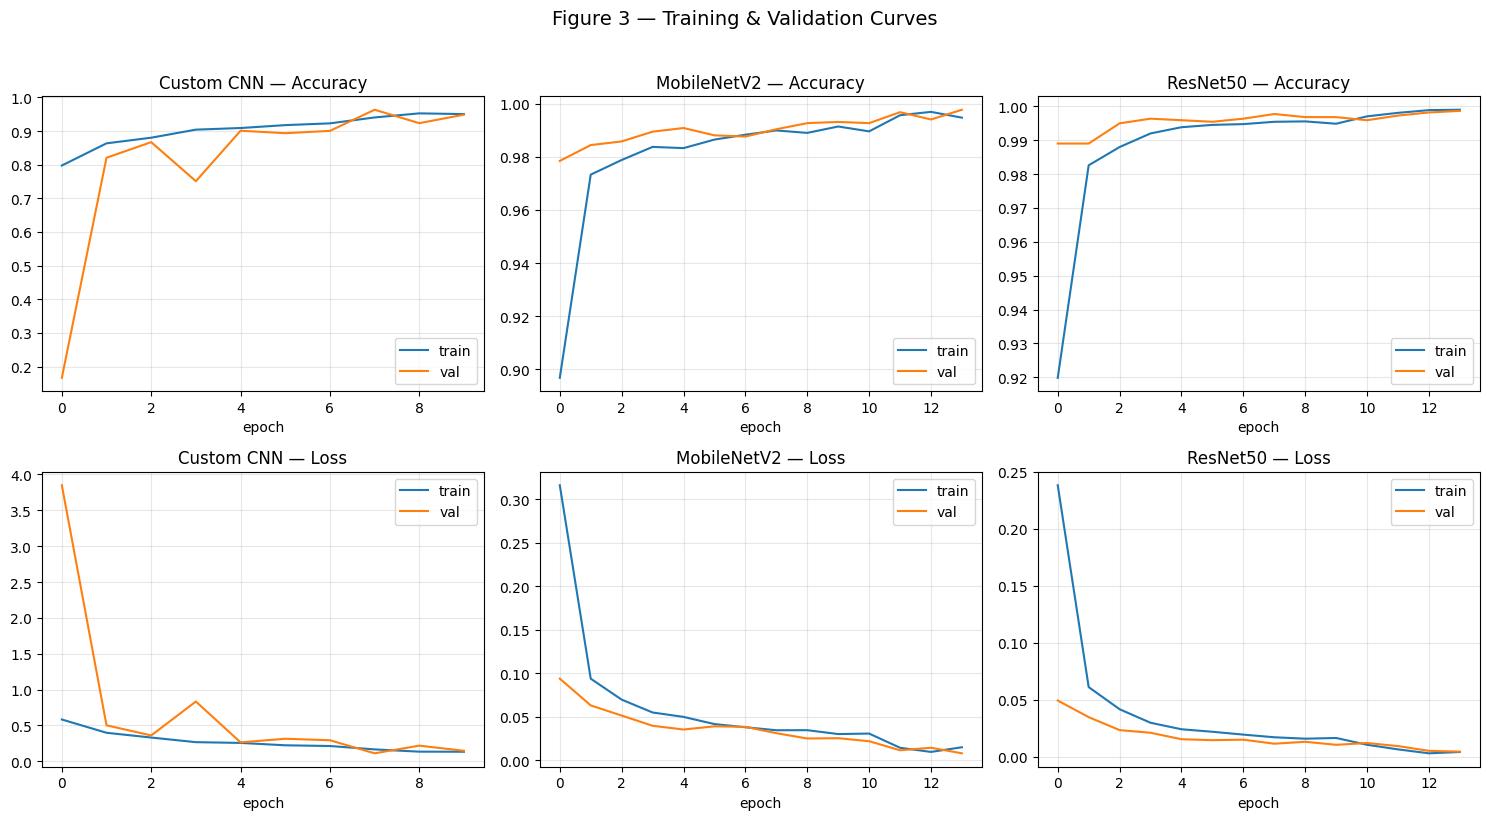

In [11]:
# ---- Figure 3: accuracy & loss curves (rows) per model (cols) ----
fig, axes = plt.subplots(2, len(MODELS), figsize=(5 * len(MODELS), 8))
for j, name in enumerate(MODELS):
    h = histories[name]
    axes[0, j].plot(h["accuracy"], label="train")
    axes[0, j].plot(h["val_accuracy"], label="val")
    axes[0, j].set_title(f"{name} — Accuracy"); axes[0, j].set_xlabel("epoch")
    axes[0, j].legend(); axes[0, j].grid(alpha=0.3)
    axes[1, j].plot(h["loss"], label="train")
    axes[1, j].plot(h["val_loss"], label="val")
    axes[1, j].set_title(f"{name} — Loss"); axes[1, j].set_xlabel("epoch")
    axes[1, j].legend(); axes[1, j].grid(alpha=0.3)
fig.suptitle("Figure 3 — Training & Validation Curves", y=1.02, fontsize=14)
plt.tight_layout()
save_fig(fig, "fig03_training_curves.pdf")
plt.show()


saved figure -> /kaggle/working/outputs/figures/fig04_confusion_matrices.pdf


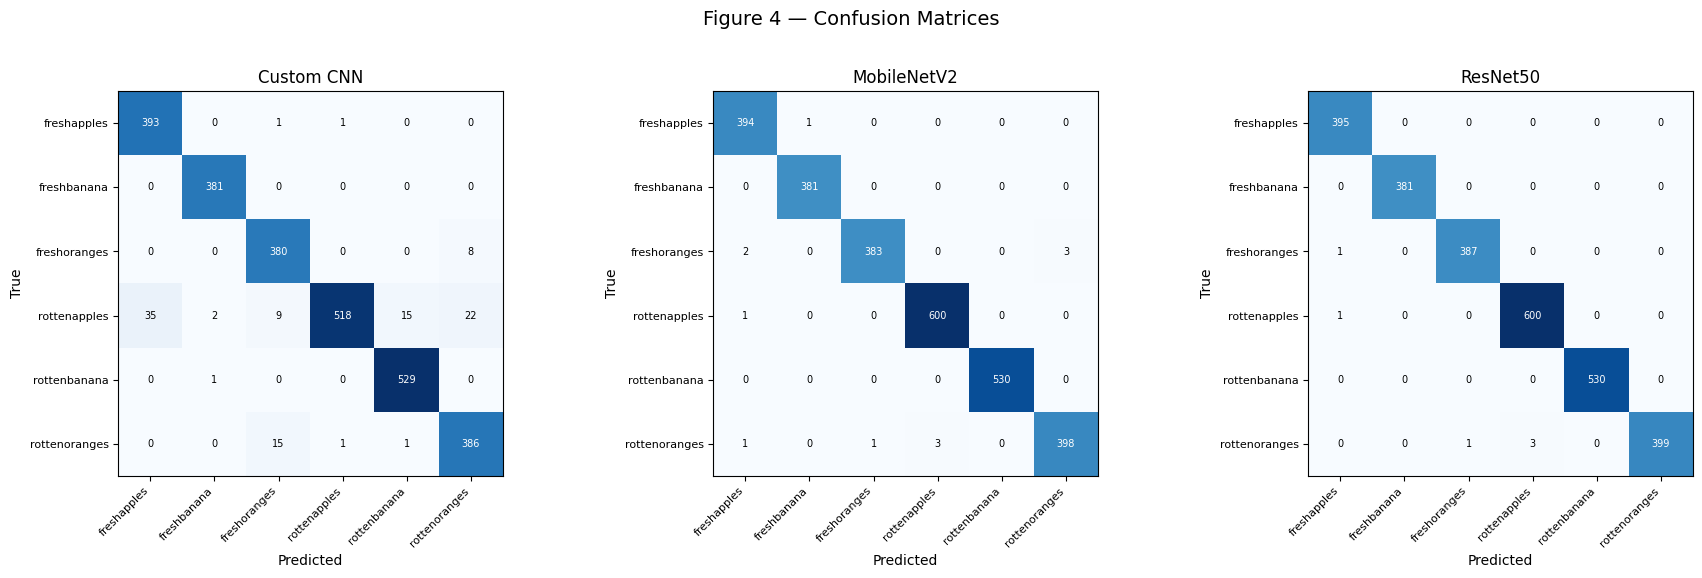

In [12]:
# ---- Figure 4: confusion matrix per model ----
fig, axes = plt.subplots(1, len(MODELS), figsize=(6 * len(MODELS), 5.5))
if len(MODELS) == 1:
    axes = [axes]
for ax, name in zip(axes, MODELS):
    cm = confusion_matrix(y_true, preds_map[name])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{name}")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(class_names, fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    thr = cm.max() / 2.0
    for r in range(NUM_CLASSES):
        for c in range(NUM_CLASSES):
            ax.text(c, r, cm[r, c], ha="center", va="center", fontsize=7,
                    color="white" if cm[r, c] > thr else "black")
fig.suptitle("Figure 4 — Confusion Matrices", y=1.03, fontsize=14)
plt.tight_layout()
save_fig(fig, "fig04_confusion_matrices.pdf")
plt.show()


## Phase 6 — Grad-CAM (Figures 5 & 6)
Each image is fed to each model using **that model's own preprocessing**, then the heatmap
is overlaid on the original. Figure 5 = correctly classified; Figure 6 = misclassified.

In [13]:
import cv2

def gradcam_heatmap(img_pre, model, last_conv, pred_index=None):
    "img_pre: preprocessed array shape (1,IMG,IMG,3)."
    grad_model = keras.Model(model.inputs,
                             [model.get_layer(last_conv).output, model.output])
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_pre)
        tape.watch(conv_out)
        if pred_index is None:
            pred_index = int(tf.argmax(preds[0]))
        channel = preds[:, pred_index]
    grads = tape.gradient(channel, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    heat = tf.squeeze(conv_out[0] @ pooled[..., tf.newaxis])
    heat = tf.maximum(heat, 0) / (tf.reduce_max(heat) + 1e-8)
    return heat.numpy(), pred_index

def overlay(img_255, heat, alpha=0.4):
    hm = cv2.resize(heat.astype("float32"), (IMG, IMG))
    hm = cv2.applyColorMap(np.uint8(255 * hm), cv2.COLORMAP_JET)
    hm = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB)
    return np.uint8(img_255 * (1 - alpha) + hm * alpha)

# One fixed batch of raw test images (0-255) to explain
sample_imgs, sample_lab = next(iter(raw_test))
sample_imgs = sample_imgs.numpy()
sample_true = np.argmax(sample_lab.numpy(), axis=1)

# Per-model predictions on the sample batch
sample_pred = {}
for name in MODELS:
    pi = preprocess_map[name](sample_imgs.copy())
    sample_pred[name] = np.argmax(models[name].predict(pi, verbose=0), axis=1)

correct_all = [i for i in range(len(sample_imgs))
               if all(sample_pred[n][i] == sample_true[i] for n in MODELS)]
mis_any = [i for i in range(len(sample_imgs))
           if any(sample_pred[n][i] != sample_true[i] for n in MODELS)]
print("correct-by-all:", len(correct_all), "| misclassified-by-some:", len(mis_any))


correct-by-all: 32 | misclassified-by-some: 0


saved figure -> /kaggle/working/outputs/figures/fig05_gradcam_correct.pdf


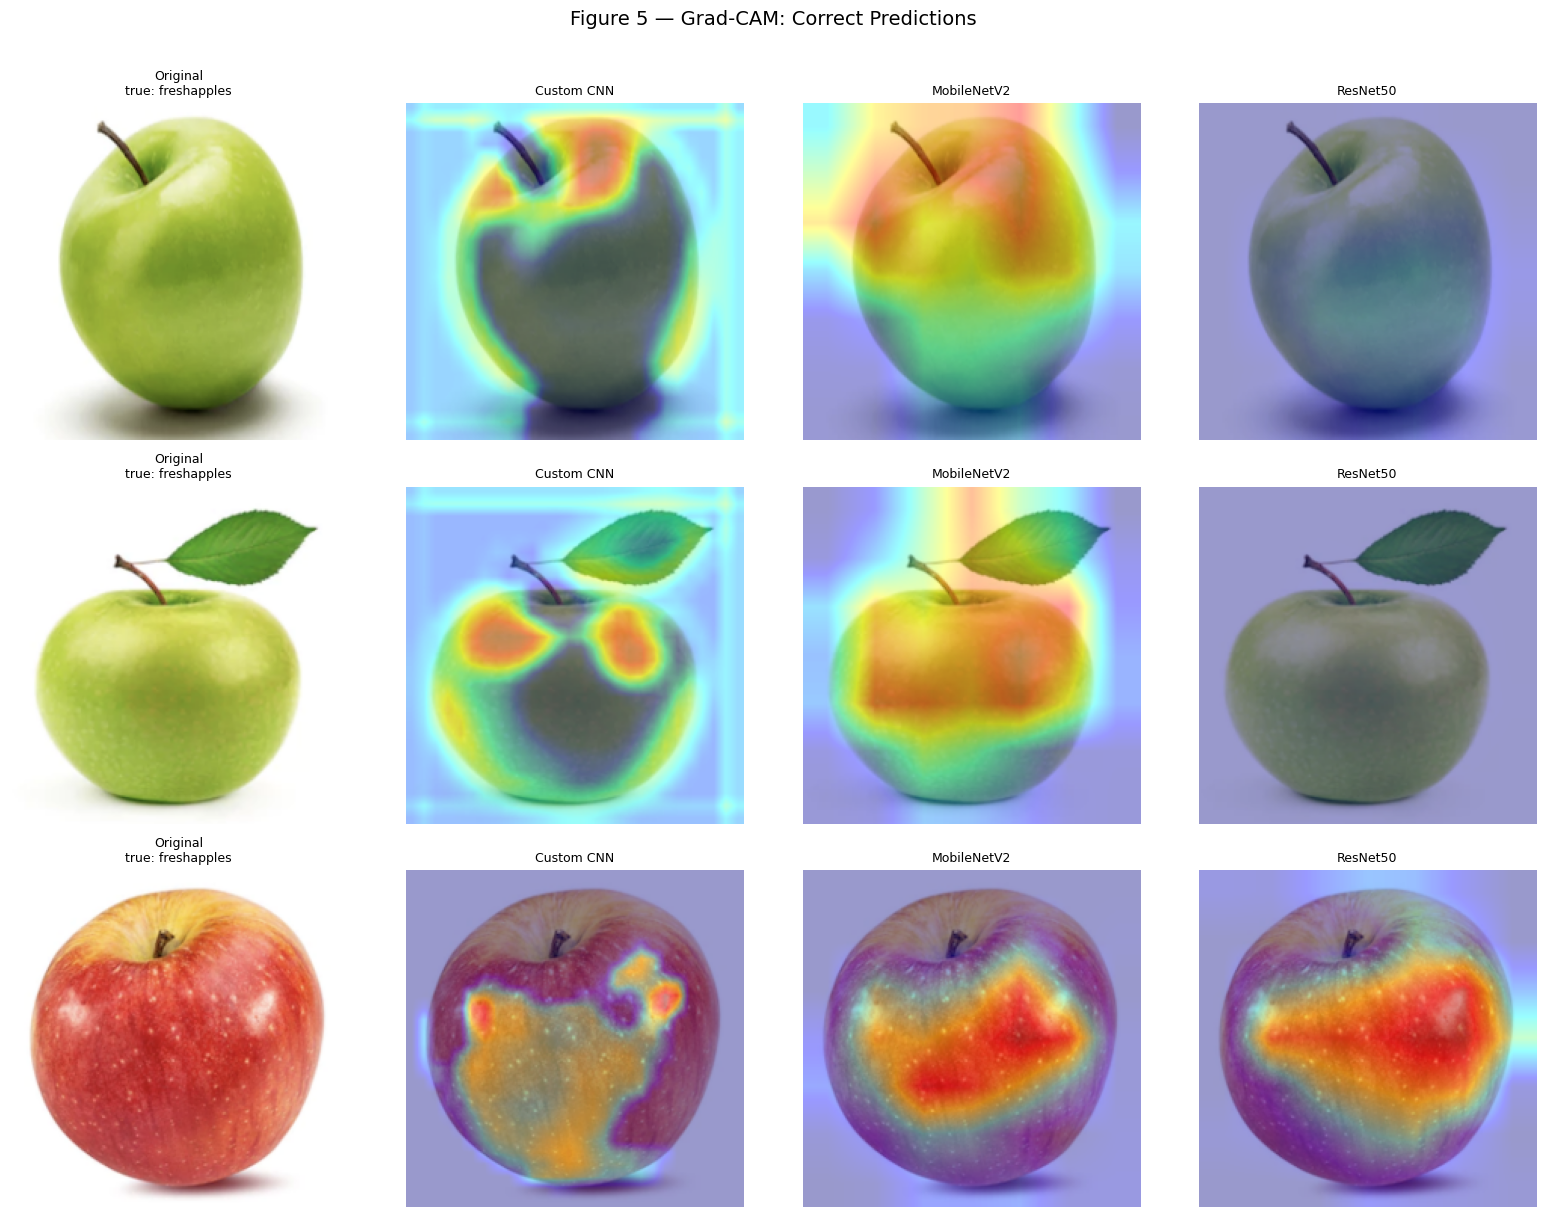

No images available for: Figure 6 — Grad-CAM: Misclassified Examples


In [14]:
def gradcam_grid(indices, title, fname, show_pred):
    indices = indices[:3] if indices else []
    if not indices:
        print("No images available for:", title); return
    nrow, ncol = len(indices), len(MODELS) + 1
    fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 4 * nrow))
    if nrow == 1:
        axes = axes.reshape(1, -1)
    for r, idx in enumerate(indices):
        raw = sample_imgs[idx]
        axes[r, 0].imshow(np.uint8(raw))
        axes[r, 0].set_title(f"Original\ntrue: {class_names[sample_true[idx]]}", fontsize=9)
        axes[r, 0].axis("off")
        for c, name in enumerate(MODELS, start=1):
            pi = preprocess_map[name](raw[None].copy())
            heat, pidx = gradcam_heatmap(pi, models[name], LAST_CONV[name])
            axes[r, c].imshow(overlay(raw, heat)); axes[r, c].axis("off")
            t = name
            if show_pred:
                ok = "OK" if pidx == sample_true[idx] else "X"
                t += f"\npred: {class_names[pidx]} [{ok}]"
            axes[r, c].set_title(t, fontsize=9)
    fig.suptitle(title, y=1.01, fontsize=14)
    plt.tight_layout()
    save_fig(fig, fname)
    plt.show()

correct_show = correct_all if correct_all else [
    i for i in range(len(sample_imgs))
    if any(sample_pred[n][i] == sample_true[i] for n in MODELS)]
gradcam_grid(correct_show, "Figure 5 — Grad-CAM: Correct Predictions",
             "fig05_gradcam_correct.pdf", show_pred=False)
gradcam_grid(mis_any, "Figure 6 — Grad-CAM: Misclassified Examples",
             "fig06_gradcam_misclassified.pdf", show_pred=True)


## Phase 6 (cont.) — SHAP (Figure 7)
Uses SHAP's image masker (black-box) so it is robust across TF/Keras versions. It explains the
top predicted class for a few test images. Wrapped in try/except so the notebook always finishes;
raise `SHAP_MAX_EVALS` for sharper maps (slower).

In [15]:
shap_saliency = {}
try:
    import shap
    Xs = sample_imgs[:SHAP_N].astype("float32")   # 0-255 raw images

    for name in MODELS:
        pf = preprocess_map[name]
        def f(z, pf=pf, name=name):
            return models[name].predict(pf(z.astype("float32").copy()), verbose=0)
        masker = shap.maskers.Image("inpaint_telea", Xs[0].shape)
        explainer = shap.Explainer(f, masker, output_names=class_names)
        sv = explainer(Xs, max_evals=SHAP_MAX_EVALS, batch_size=50,
                       outputs=shap.Explanation.argsort.flip[:1])
        vals = np.array(sv.values)
        if vals.ndim == 5:          # (N,H,W,3,1) -> (N,H,W,3)
            vals = vals[..., 0]
        shap_saliency[name] = np.abs(vals).sum(axis=-1)   # (N,H,W)
        print("SHAP done:", name)
except Exception as e:
    print("SHAP step skipped due to:", repr(e))


  0%|          | 0/298 [00:00<?, ?it/s]

PartitionExplainer explainer:  33%|███▎      | 1/3 [00:00<?, ?it/s]

  0%|          | 0/298 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 3/3 [00:31<00:00,  5.78s/it]

  0%|          | 0/298 [00:00<?, ?it/s]

...

  0%|          | 0/298 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 3/3 [00:40<00:00,  6.22s/it]

  0%|          | 0/298 [00:00<?, ?it/s]

PartitionExplainer explainer: 4it [00:53, 17.79s/it]                       

SHAP done: ResNet50


saved figure -> /kaggle/working/outputs/figures/fig07_shap.pdf


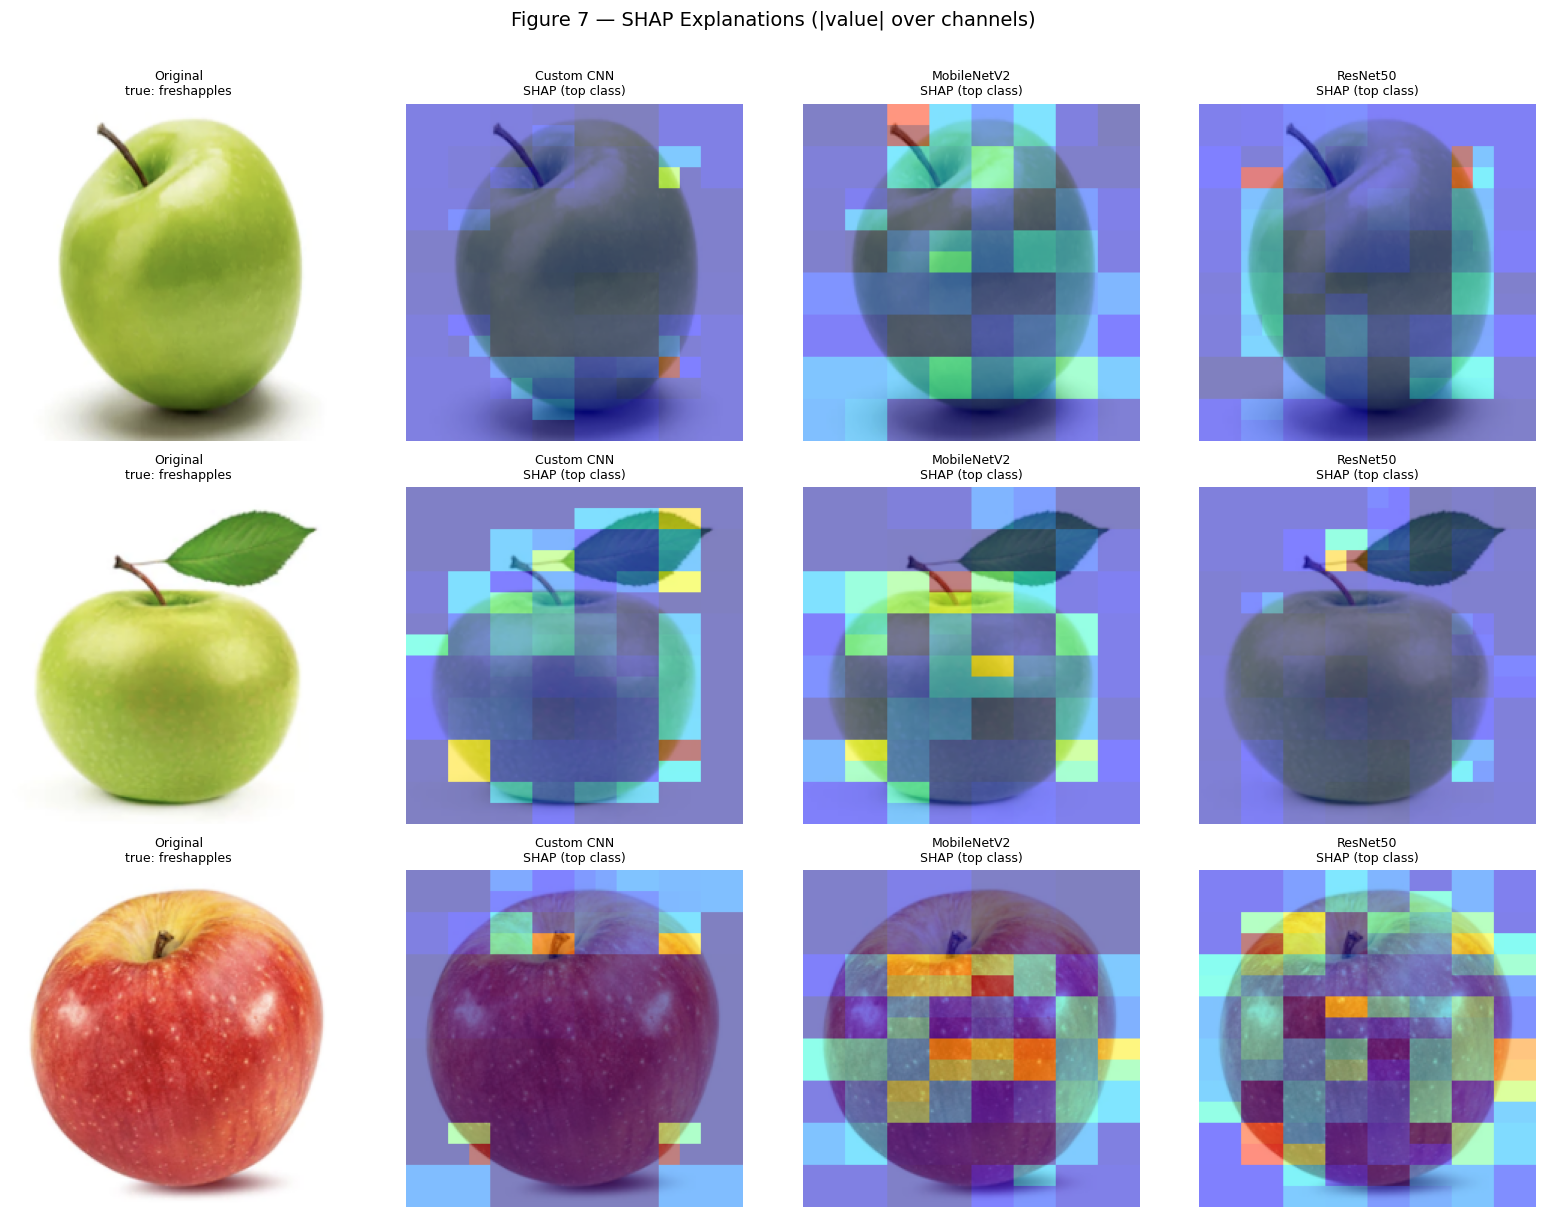

In [16]:
if shap_saliency:
    nrow, ncol = SHAP_N, len(MODELS) + 1
    fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 4 * nrow))
    if nrow == 1:
        axes = axes.reshape(1, -1)
    for r in range(SHAP_N):
        axes[r, 0].imshow(np.uint8(sample_imgs[r]))
        axes[r, 0].set_title(f"Original\ntrue: {class_names[sample_true[r]]}", fontsize=9)
        axes[r, 0].axis("off")
        for c, name in enumerate(MODELS, start=1):
            sal = shap_saliency[name][r]
            sal = (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)
            axes[r, c].imshow(np.uint8(sample_imgs[r]))
            axes[r, c].imshow(sal, cmap="jet", alpha=0.5)
            axes[r, c].set_title(f"{name}\nSHAP (top class)", fontsize=9)
            axes[r, c].axis("off")
    fig.suptitle("Figure 7 — SHAP Explanations (|value| over channels)", y=1.01, fontsize=14)
    plt.tight_layout()
    save_fig(fig, "fig07_shap.pdf")
    plt.show()
else:
    print("No SHAP saliency to plot (see message above).")


## Phase 7 — Final comparison table + workflow diagram (Figure 2)
`final_comparison.csv` holds the numeric results. The **Grad-CAM Quality**,
**SHAP Interpretability** and **Overall Finding** columns are intentionally left blank —
fill them in yourself after inspecting Figures 5–7 (numbers here are never fabricated).

In [17]:
final = eval_df[["Accuracy", "F1-Score", "Training Time (s)", "Parameters"]].copy()
final["Grad-CAM Quality"]      = ""   # fill: High / Medium / Low
final["SHAP Interpretability"] = ""   # fill: 1 (unclear) .. 5 (highly meaningful)
final["Overall Finding"]       = ""   # fill: your one-line conclusion
print(final)
save_table(final, "final_comparison.csv")


             Accuracy  F1-Score  Training Time (s)  Parameters  \
Model                                                            
Custom CNN     0.9589    0.9601              500.1      259526   
MobileNetV2    0.9956    0.9952              726.2     2265670   
ResNet50       0.9978    0.9978              830.9    23600006   

            Grad-CAM Quality SHAP Interpretability Overall Finding  
Model                                                               
Custom CNN                                                          
MobileNetV2                                                         
ResNet50                                                            
saved table  -> /kaggle/working/outputs/tables/final_comparison.csv


saved figure -> /kaggle/working/outputs/figures/fig02_workflow.pdf


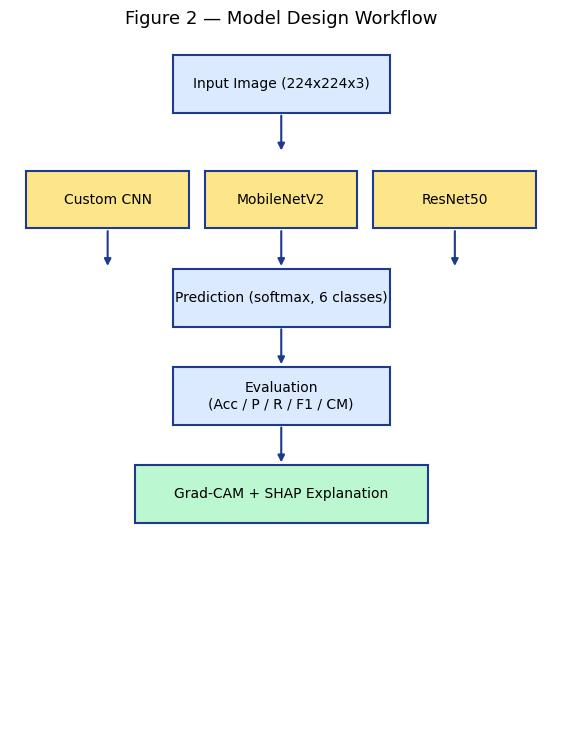

In [19]:
# ---- Figure 2: model design workflow diagram ----
fig, ax = plt.subplots(figsize=(7, 9)); ax.axis("off")
ax.set_xlim(0, 10); ax.set_ylim(0, 12)

def box(x, y, w, h, text, color="#dbeafe"):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=color,
                               edgecolor="#1e3a8a", lw=1.5))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=10)

def arrow(x, y0, y1):
    ax.annotate("", xy=(x, y1), xytext=(x, y0),
                arrowprops=dict(arrowstyle="-|>", lw=1.5, color="#1e3a8a"))

box(3, 10.6, 4, 1, "Input Image (224x224x3)")
arrow(5, 10.6, 9.9)
box(0.3, 8.6, 3, 1.0, "Custom CNN", "#fde68a")
box(3.6, 8.6, 2.8, 1.0, "MobileNetV2", "#fde68a")
box(6.7, 8.6, 3.0, 1.0, "ResNet50", "#fde68a")
for cx in (1.8, 5.0, 8.2):
    arrow(cx, 8.6, 7.9)
box(3, 6.9, 4, 1, "Prediction (softmax, 6 classes)")
arrow(5, 6.9, 6.2)
box(3, 5.2, 4, 1, "Evaluation\n(Acc / P / R / F1 / CM)")
arrow(5, 5.2, 4.5)
box(2.3, 3.5, 5.4, 1, "Grad-CAM + SHAP Explanation", "#bbf7d0")
ax.set_title("Figure 2 — Model Design Workflow", fontsize=13)
save_fig(fig, "fig02_workflow.pdf")
plt.show()


## Phase 8 — Inventory of saved outputs
Everything below is written under `/kaggle/working/outputs/` and persists as notebook output.

In [20]:
print("FIGURES (PDF):")
for f in sorted(os.listdir(FIG_DIR)):
    print("  ", f)
print("\nTABLES (CSV):")
for f in sorted(os.listdir(TAB_DIR)):
    print("  ", f)
print("\nMODELS / SUMMARIES:")
for f in sorted(os.listdir(MODEL_DIR)):
    print("  ", f)
print("\nAll deliverables are in:", OUT)


FIGURES (PDF):
   fig01_dataset_samples.pdf
   fig02_workflow.pdf
   fig03_training_curves.pdf
   fig04_confusion_matrices.pdf
   fig05_gradcam_correct.pdf
   fig07_shap.pdf

TABLES (CSV):
   classification_report_Custom_CNN.csv
   classification_report_MobileNetV2.csv
   classification_report_ResNet50.csv
   confusion_matrix_Custom_CNN.csv
   confusion_matrix_MobileNetV2.csv
   confusion_matrix_ResNet50.csv
   dataset_description.csv
   evaluation_results.csv
   final_comparison.csv
   model_architecture.csv

MODELS / SUMMARIES:
   Custom_CNN.keras
   MobileNetV2.keras
   ResNet50.keras
   summary_Custom_CNN.txt
   summary_MobileNetV2.txt
   summary_ResNet50.txt

All deliverables are in: /kaggle/working/outputs


In [21]:
# ============================================================
# Download all outputs as a single ZIP
# ============================================================
import os, shutil
from IPython.display import FileLink, display

INCLUDE_MODELS = True   # set False to exclude the heavy .keras model files (much smaller zip)

OUT = globals().get("OUT", "/kaggle/working/outputs")
ZIP_PATH = "/kaggle/working/fruit_freshness_outputs.zip"

if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)

# Build the zip
shutil.make_archive(ZIP_PATH[:-4], "zip", OUT)

# Optionally rebuild without the models folder
if not INCLUDE_MODELS:
    os.remove(ZIP_PATH)
    tmp = "/kaggle/working/_zip_tmp"
    if os.path.exists(tmp):
        shutil.rmtree(tmp)
    shutil.copytree(OUT, tmp, ignore=shutil.ignore_patterns("models"))
    shutil.make_archive(ZIP_PATH[:-4], "zip", tmp)
    shutil.rmtree(tmp)

size_mb = os.path.getsize(ZIP_PATH) / 1e6
print(f"ZIP ready: {ZIP_PATH}  ({size_mb:.2f} MB)")
print("Click the link below to download:")
display(FileLink(ZIP_PATH))

ZIP ready: /kaggle/working/fruit_freshness_outputs.zip  (220.63 MB)
Click the link below to download:


/kaggle/working/fruit_freshness_outputs.zip